# Preparation

In [306]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import truncnorm, mode
import numpy as np

In [307]:
import matplotlib.font_manager
from IPython.core.display import HTML

def make_html(fontname):
    return "<p>{font}: <span style='font-family:{font}; font-size: 24px;'>{font}</p>".format(font=fontname)

code = "\n".join([make_html(font) for font in sorted(set([f.name for f in matplotlib.font_manager.fontManager.ttflist]))])

sns.set_theme(style='white', font_scale=1.2)
TIP_colors =  ["#1B4355", "#CB7A2C", "#7A8F50"]
sns.set_palette(TIP_colors)

# HTML("<div style='column-count: 2;'>{}</div>".format(code))
sns.color_palette(TIP_colors)

[(0.10588235294117647, 0.2627450980392157, 0.3333333333333333),
 (0.796078431372549, 0.47843137254901963, 0.17254901960784313),
 (0.47843137254901963, 0.5607843137254902, 0.3137254901960784)]

## Data Cleaning of TIP_StudentData

In [308]:
df_student = pd.read_csv(r'TIP_StudentData.csv', parse_dates=['DOB', 'GraduatedDate', 'InterviewedDate','StartDate','EndDate'])
df_race = pd.read_csv(r'tip_cohort_demographics_rg.csv')[['tip_id', 'census_tract', 'gender', 'race']]

df_student["tip_id"].nunique()

2307

In [309]:
# define status
def status(row):
    if not pd.isnull(row['GraduatedDate']):
        return 'Graduated'
    elif (not pd.isnull(row['StartDate'])) & (not pd.isnull(row['EndDate'])) & ((row['EndDate'] - row['StartDate']).days < 78):
        return 'Non Graduated'
    elif (not pd.isnull(row['InterviewedDate'])) & ((pd.isnull(row['EndDate'])) or (row['EndDate'] - row['InterviewedDate']).days < 78):
        return 'Interviewed'
    else:
        return 'None'
    
df_student['Status'] = df_student.apply(status, axis=1)

In [310]:
# ensure datetime
for c in ["DOB", "StartDate", "InterviewedDate"]:
    if c in df_student.columns:
        df_student[c] = pd.to_datetime(df_student[c], errors="coerce")

# calculate age based on status
age_from_start = (df_student["StartDate"] - df_student["DOB"]).dt.days / 365.25
age_from_interview = (df_student["InterviewedDate"] - df_student["DOB"]).dt.days / 365.25

df_student["age"] = np.select(
    [
        df_student["Status"].isin(["Graduated", "Non Graduated"]),
        df_student["Status"].eq("Interviewed"),
    ],
    [
        np.floor(age_from_start),
        np.floor(age_from_interview),
    ],
    default=np.nan
)

# pre/post 2022 cohort based on StartDate
cutoff = pd.Timestamp("2022-01-01")
df_student["cohort_2022"] = np.where(
    df_student["StartDate"].notna(),
    np.where(df_student["StartDate"] >= cutoff, 2, 1),
    "N/A"
)

# start year
df_student["StartYear"] = df_student["StartDate"].dt.year

# drop DOB
df_student = df_student.drop(columns=["DOB"], errors="ignore")

In [311]:
df_not_none = df_student[df_student['Status'] != 'None'].copy()

In [312]:
df = pd.merge(
    df_not_none,
    df_race,
    on='tip_id',
    how='left'
)

In [313]:
df['StartYear'] = df.apply(lambda x: int(x['StartDate'].year) if not pd.isnull(x['StartDate']) else int(x['InterviewedDate'].year), axis=1)

In [314]:
max_date = '2025-03-03'

def valid_years(row):
    if not pd.isnull(row['GraduatedDate']):
        return (pd.to_datetime(max_date) - row['GraduatedDate']).days / 365.25
    elif not pd.isnull(row['EndDate']):
        return (pd.to_datetime(max_date) - row['EndDate']).days / 365.25
    elif not pd.isnull(row['StartDate']):
        return (pd.to_datetime(max_date) - row['StartDate']).days / 365.25
    elif not pd.isnull(row['InterviewedDate']):
        return (pd.to_datetime(max_date) - row['InterviewedDate']).days / 365.25
    else:
        return None

df['ValidYears'] = df.apply(valid_years, axis=1)
df.sample(10)

min_date = '2017-01-01'

def valid_years_pre(row):
    if not pd.isnull(row['StartDate']):
        return (pd.to_datetime(min_date) - row['StartDate']).days/365.25
    elif not pd.isnull(row['InterviewedDate']):
        return(pd.to_datetime(min_date) - row['InterviewedDate']).days/365.25
    else:
        return None

df['ValidYearsPre']= df.apply(valid_years_pre, axis=1)

df.head()

,tip_id,GraduatedDate,InterviewedDate,StartDate,EndDate,DriversLicense,Course,CreatedDate,Status,age,cohort_2022,StartYear,census_tract,gender,race,ValidYears,ValidYearsPre
0,1,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11,Non Graduated,25.0,1,2018,4.200356e+10,Male,Black,6.587269,-1.524983
1,4,2013-10-16,NaT,2013-08-12,2013-10-16,NaN,Introduction to Masonry,2018-07-12,Graduated,30.0,1,2013,4.200313e+10,Male,Black,11.378508,3.389459
2,5,2011-02-04,NaT,2010-11-29,2011-02-04,NaN,Introduction to Masonry,2018-07-12,Graduated,22.0,1,2010,NaN,NaN,NaN,14.075291,6.091718
3,6,NaT,NaT,2013-07-24,2013-09-06,NaN,Introduction to Masonry,2018-07-12,Non Graduated,28.0,1,2013,4.212981e+10,Male,Black,11.488022,3.441478
4,7,NaT,NaT,2013-08-19,2013-08-27,NaN,Introduction to Masonry,2018-07-12,Non Graduated,23.0,1,2013,4.211102e+10,Male,Black,11.515400,3.370294


## Data Cleaning of TIP_MergedSentencingData

In [315]:
df_convictions = pd.read_csv(r'TIP_MergedSentencingData.csv', parse_dates=['DOF', 'DOS', 'StartDate', 'InterviewedDate', 'EndDate', 'GraduatedDate'])
df_convictions = df_convictions[df_convictions['offense_indicator'] == 1]
df_convictions['OffenseBeforeStart'] = df_convictions.apply(lambda x: x['DOS'] < x['StartDate'] if not pd.isnull(x['StartDate']) else (x['DOS'] < x['InterviewedDate'] if not pd.isnull(x['InterviewedDate']) else False), axis=1)

In [316]:
df['OffenseBeforeStart'] = df['tip_id'].apply(lambda x: x in df_convictions[df_convictions['OffenseBeforeStart'] == True]['tip_id'].unique())

In [317]:
df_convictions.head()

,tip_id,DOB,GraduatedDate,InterviewedDate,StartDate,EndDate,DriversLicense,Course,CreatedDate,DOF,DOS,OGS,INCMIN,PCS_OFF_ID,YearsSinceTIP,offense_indicator,OffenseBeforeStart
0,1,1992-08-26,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11,2016-01-09,2016-07-12,9.0,NaN,1068451.0,-2.505185,1,True
1,1,1992-08-26,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11,2016-01-09,2016-07-12,3.0,NaN,1068451.0,-2.505185,1,True
2,1,1992-08-26,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11,2016-01-09,2016-07-12,10.0,NaN,1068451.0,-2.505185,1,True
3,2,1997-01-27,NaT,NaT,2018-07-12,NaT,No,Introduction to Masonry,2018-07-11,2017-05-02,2018-05-22,9.0,NaN,1041834.0,-1.193727,1,True
4,2,1997-01-27,NaT,NaT,2018-07-12,NaT,No,Introduction to Masonry,2018-07-11,2017-05-02,2018-05-22,1.0,0.131579,1041834.0,-1.193727,1,True


In [318]:
df_convictions = pd.merge(
    df_convictions,
    df_student[['tip_id', 'cohort_2022']],
    on='tip_id',
    how='left'
)
df_convictions['cohort_2022'] = pd.to_numeric(df_convictions['cohort_2022'], errors='coerce')
df_convictions.head

df_convictions = pd.merge(
    df_convictions,
    df[['tip_id','ValidYears','Status']],
    on='tip_id',
    how='left'
)
df_convictions.head

<bound method NDFrame.head of       tip_id         DOB GraduatedDate InterviewedDate  StartDate    EndDate  \
0          1  1992-08-26           NaT             NaT 2018-07-12 2018-08-01   
1          1  1992-08-26           NaT             NaT 2018-07-12 2018-08-01   
2          1  1992-08-26           NaT             NaT 2018-07-12 2018-08-01   
3          2  1997-01-27           NaT             NaT 2018-07-12        NaT   
4          2  1997-01-27           NaT             NaT 2018-07-12        NaT   
...      ...         ...           ...             ...        ...        ...   
5502    2307  1985-04-04           NaT      2025-01-30        NaT        NaT   
5503    2307  1985-04-04           NaT      2025-01-30        NaT        NaT   
5504    2307  1985-04-04           NaT      2025-01-30        NaT        NaT   
5505    2307  1985-04-04           NaT      2025-01-30        NaT        NaT   
5506    2309  1995-07-13           NaT      2025-01-30        NaT        NaT   

     Driv

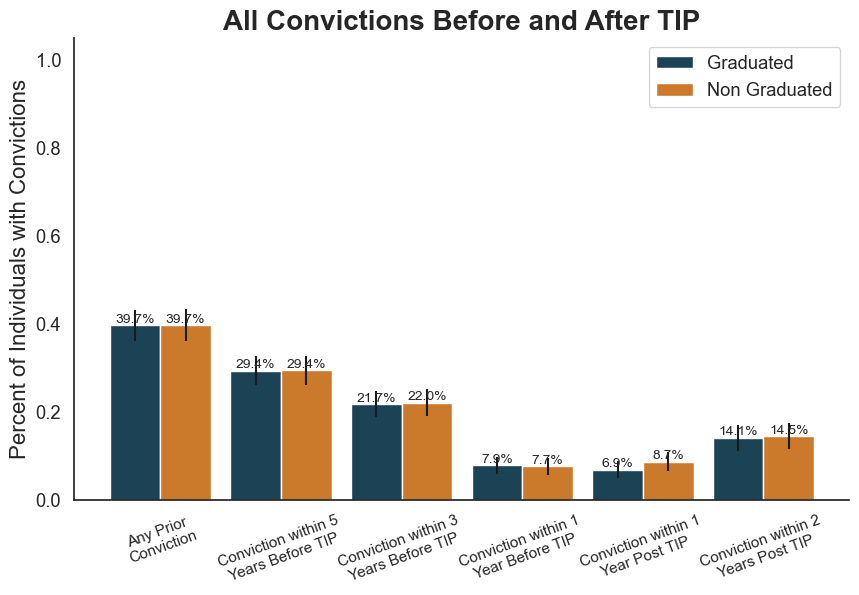

In [319]:
# ================
# CONFIG FOR FULL (COHORT 1+2)
# ================

# keep only Graduated / Non Graduated
off = df_convictions.copy()
off = off[off["Status"].isin(["Graduated", "Non Graduated"])].copy()

# -----------------------------
# 1) PRE cumulative bins
# -----------------------------

pre_bins = {
    -1: [-1],             # 1 year pre
    -3: [-3, -2, -1],     # 1-3 years pre
    -5: [-5,-4,-3,-2,-1],  #1-5 years pre
    -30: list(range(-30, 0))  # any prior usage
}

off["YearsSinceTIP_int"] = off["YearsSinceTIP"].round().astype(int)

rows = []
for bin_edge, years in pre_bins.items():
    cur = off[off["YearsSinceTIP_int"].isin(years)]
    
    row = {"YearsSinceTIP": bin_edge}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        row[status] = num
        
    rows.append(row)

pre_count = pd.DataFrame(rows)

# denominators for pre: total people per status

denom_pre = (
    df[(df["Status"].isin(["Graduated", "Non Graduated"]))]
    .groupby("Status")["tip_id"]
    .nunique()
    .to_dict()
)

z = 1.96
for status in ["Graduated", "Non Graduated"]:
    pre_count[f"{status} Percent"] = pre_count[status] / denom_pre.get(status, np.nan)
    p = pre_count[f"{status} Percent"]
    n = denom_pre.get(status, np.nan)
    se = np.sqrt(p * (1 - p) / n)
    pre_count[f"{status}_Upper_CI"] = (p + z * se).clip(0, 1)
    pre_count[f"{status}_Lower_CI"] = (p - z * se).clip(0, 1)

# -----------------------------
# 3) POST: cumulative windows [0, i) for i = 1,2 and require ValidYears > i
# -----------------------------
post_points = [1, 2]
rows = []

for i in post_points:
    cur = off[(off["YearsSinceTIP"] >= 0) & (off["YearsSinceTIP"] < i) & (off["ValidYears"] >= i)]

    row = {"YearsSinceTIP": i}
    for status in ["Graduated", "Non Graduated"]:
        num = cur.loc[cur["Status"] == status, "tip_id"].nunique()
        denom = df.loc[(df["Status"] == status) & (df["ValidYears"] >= i), "tip_id"].nunique()

        p = (num / denom) if denom > 0 else 0
        se = np.sqrt(p * (1 - p) / denom) if denom > 0 else np.nan

        row[f"{status}"] = num
        row[f"{status} Percent"] = p
        row[f"{status}_Upper_CI"] = min(1, p + z * se) if denom > 0 else np.nan
        row[f"{status}_Lower_CI"] = max(0, p - z * se) if denom > 0 else np.nan

    rows.append(row)

post_df = pd.DataFrame(rows)

# -----------------------------
# 4) assemble 6 categories + plot
# -----------------------------
label_map = {
    -30: "Any Prior\nConviction",
    -5: "Conviction within 5\nYears Before TIP",
    -3:  "Conviction within 3\nYears Before TIP",
    -1:  "Conviction within 1\nYear Before TIP",
     1:  "Conviction within 1\nYear Post TIP",
     2:  "Conviction within 2\nYears Post TIP"
}
order = [-30, -5, -3, -1, 1, 2]

pre_keep = pre_count[pre_count["YearsSinceTIP"].isin([-30, -5, -3, -1])].copy()
data = pd.concat([pre_keep, post_df], ignore_index=True)

data["label"] = data["YearsSinceTIP"].astype(int).map(label_map)
data["YearsSinceTIP"] = data["YearsSinceTIP"].astype(int)
data["YearsSinceTIP"] = pd.Categorical(data["YearsSinceTIP"], categories=order, ordered=True)
data = data.sort_values("YearsSinceTIP").reset_index(drop=True)


grad_err = np.abs(
    data[["Graduated_Upper_CI", "Graduated_Lower_CI"]].T.values - data["Graduated Percent"].values
)
non_grad_err = np.abs(
    data[["Non Graduated_Upper_CI", "Non Graduated_Lower_CI"]].T.values - data["Non Graduated Percent"].values
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(data))
width = 0.42

ax.bar(x - width/2, data["Graduated Percent"], width=width, label="Graduated", yerr=grad_err, capsize=0)
ax.bar(x + width/2, data["Non Graduated Percent"], width=width, label="Non Graduated", yerr=non_grad_err, capsize=0)

ax.set_xticks(x)
ax.set_xticklabels(data["label"], rotation=20, ha="center", fontsize=11)

for xi, yi in zip(x - width/2, data["Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)
for xi, yi in zip(x + width/2, data["Non Graduated Percent"]):
    ax.text(xi, yi, f"{yi:.1%}", ha="center", va="bottom", fontsize=10)

sns.despine()
plt.title("All Convictions Before and After TIP", fontdict={"fontsize": 20, "fontweight": "semibold"})
plt.ylabel("Percent of Individuals with Convictions", fontdict={"fontsize": 16})
plt.ylim(0, 1.05)
plt.legend(loc="upper right")
plt.show()


## Data Cleaning of arrest_data

In [320]:
df_arrests = pd.read_csv('arrest_data.csv', parse_dates=['ArrestDate', 'StartDate', 'EndDate', 'InterviewedDate', 'GraduatedDate'])
df_arrests['ArrestBeforeStart'] = df_arrests.apply(lambda x: x['ArrestDate'] < x['StartDate'] if not pd.isnull(x['StartDate']) else (x['ArrestDate'] < x['InterviewedDate'] if not pd.isnull(x['InterviewedDate']) else False), axis=1)

In [321]:
df['ArrestBeforeStart'] = df['tip_id'].apply(lambda x: x in df_arrests[df_arrests['ArrestBeforeStart'] == True]['tip_id'].unique())

## OGS

In [322]:
df_convictions_ogs = df_convictions.dropna(subset=['Status']).copy()
df_convictions_ogs = df_convictions_ogs[df_convictions_ogs['OffenseBeforeStart'] == True]
df_convictions_ogs['StartYear'] = df_convictions_ogs.apply(lambda x: x['StartDate'].year if not pd.isnull(x['StartDate']) else x['InterviewedDate'].year, axis=1)
df_convictions_ogs = df_convictions_ogs[df_convictions_ogs['Status'] != 'Interviewed']
df_convictions_ogs['Status'] = pd.Categorical(df_convictions_ogs['Status'], categories=["Graduated", "Non Graduated"], ordered=True)
df_convictions_ogs['OGS'] = df_convictions_ogs['OGS'].astype(int)

In [323]:
# The records with same tip_id, DOF, OGS, and Status are treated as duplicates
df_convictions_ogs = df_convictions_ogs.drop_duplicates(subset=["tip_id", "DOF", "OGS", "Status"])

ogs_df = pd.DataFrame(df_convictions_ogs.groupby(['OGS', 'Status']).size()).reset_index()
ogs_df.columns = ['OGS', 'Status', 'Count']
ogs_df['Percentage'] = ogs_df['Count'] / ogs_df['Count'].sum()
ogs_df = ogs_df.pivot(index='OGS', columns='Status', values=['Percentage', 'Count'])
ogs_df.columns = ['Graduated_Percentage', 'Non Graduated_Percentage', 'Graduated_Count', 'Non Graduated_Count']
ogs_df = ogs_df.reset_index()

C:\Users\13429\AppData\Local\Temp\ipykernel_25092\1743254842.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ogs_df = pd.DataFrame(df_convictions_ogs.groupby(['OGS', 'Status']).size()).reset_index()


## Criminal Justice Interactions

In [324]:
def years_since_TIP(row):
    val = 0
    dof = row['DOF']
    if not pd.isnull(row['StartDate']):
        start = row['StartDate']
    else:
        start = row['InterviewedDate']
    if not pd.isnull(row['GraduatedDate']):
        end = row['GraduatedDate']
    else:
        end = row['EndDate']

    if pd.isnull(start) and pd.isnull(end):
        return None

    if dof > start:
        val = (dof - end).days/365.2425
    elif dof < start:
        val = -(start - dof).days/365.2425
    return val

df_convictions['YearsSinceTIP'] = df_convictions.apply(years_since_TIP, axis=1)

In [325]:
df_arrests.columns

Index(['County', 'DocketNumber', 'OTN', 'CaseFiledDate', 'ArrestDate',
       'DefendantRace', 'DefendantEthnicity', 'DefendantGender',
       'DefendantDOB', 'DefendantZipCode', 'OffenseSequenceNumber', 'Title',
       'Section', 'SubSection', 'Description', 'OffenseDate',
       'OffenseDisposition', 'OffenseDispositionDate', 'OffenseGrade',
       'CaseDisposition', 'CaseDispositionDate',
       'DefendantAttorneyRepresentationType', 'InterviewedDate',
       'Orientation Date', 'GraduatedDate', 'CreatedDate', 'StartDate',
       'EndDate', 'DriversLicense', 'Course', 'tip_id',
       'OriginatingDocketNumber', 'OrigFiledDate', 'ArrestBeforeStart'],
      dtype='object')

In [326]:
df_arrests = pd.merge(
    df_arrests,
    df[['tip_id', 'Status', 'ValidYears']],
    on='tip_id',
    how='left'
)

In [327]:
df_arrests['DOF'] = df_arrests['ArrestDate']
df_arrests['YearsSinceTIP'] = df_arrests.apply(years_since_TIP, axis=1)

In [328]:
df.columns

Index(['tip_id', 'GraduatedDate', 'InterviewedDate', 'StartDate', 'EndDate',
       'DriversLicense', 'Course', 'CreatedDate', 'Status', 'age',
       'cohort_2022', 'StartYear', 'census_tract', 'gender', 'race',
       'ValidYears', 'ValidYearsPre', 'OffenseBeforeStart',
       'ArrestBeforeStart'],
      dtype='object')

## Data Cleaning of tip_cohort_uiearnings and Employment Descriptive Analysis

In [329]:
df_earnings = pd.read_csv(r'tip_cohort_uiearnings.csv')
df_inflation = pd.read_csv(r'inflation_data.csv')

df_earnings["tip_id"].nunique()

C:\Users\13429\AppData\Local\Temp\ipykernel_25092\2636283988.py:1: DtypeWarning: Columns (3,6,7,8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_earnings = pd.read_csv(r'tip_cohort_uiearnings.csv')


2142

In [330]:
# process quarter to datetime
q_str = df_earnings["quarter"].astype(str).str.strip()

df_earnings["year"] = q_str.str[:4].astype(int)
df_earnings["qnum"] = q_str.str[-1].astype(int)  # 1-4

# map to calendar quarter end month/day
# Q1 -> 03/31
# Q2 -> 06/30
# Q3 -> 09/30
# Q4 -> 12/31 
month_map = {1: 3, 2: 6, 3: 9, 4: 12}
day_map   = {1: 31, 2: 30, 3: 30, 4: 31}

df_earnings["cal_end_year"] = df_earnings["year"]
df_earnings["cal_end_month"] = df_earnings["qnum"].map(month_map)
df_earnings["cal_end_day"] = df_earnings["qnum"].map(day_map)

df_earnings["year_quarter_dt"] = pd.to_datetime(
    dict(
        year=df_earnings["cal_end_year"],
        month=df_earnings["cal_end_month"],
        day=df_earnings["cal_end_day"],
    ),
    errors="coerce",
)

df_earnings["year_month"] = df_earnings["year_quarter_dt"].dt.to_period("M")
df_earnings.drop(columns=["Unnamed: 0", "qnum", "cal_end_year", "cal_end_month", "cal_end_day"], errors="ignore", inplace=True)

In [331]:
df_earnings.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,naics_industry_2022,year,year_quarter_dt,year_month
0,655,20182,LEHIGH VALLEY RESTAURANT GROUP INC,1434,722511.0,Accommodation and food services,Food services and drinking places,Full-Service Restaurants,Accommodation and Food Services,Food Services and Drinking Places,Full-Service Restaurants,2018,2018-06-30,2018-06
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03


In [332]:
# adjust income data for inflation
df_inflation.drop(columns=['HALF1', 'HALF2'], inplace=True)
df_inflation = df_inflation.melt(id_vars='Year', var_name='Month', value_name='CPI')

month_map = {'Jan':'01','Feb':'02','Mar':'03','Apr':'04','May':'05','Jun':'06',
             'Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
df_inflation["year_month"] = (
    df_inflation["Year"].astype(str) + "-" + df_inflation["Month"].map(month_map)
)
# sort by date to ensure that the latest CPI value is at the end of the DataFrame
df_inflation = df_inflation.sort_values("year_month").reset_index(drop=True)
latest_cpi = df_inflation.loc[df_inflation["year_month"] == "2025-12", "CPI"].iloc[0]

df_earnings["year_month"] = df_earnings["year_month"].astype(str)

cpi_map = df_inflation.drop_duplicates("year_month").set_index("year_month")["CPI"]
df_earnings["CPI"] = df_earnings["year_month"].map(cpi_map)

df_earnings["adjusted_earnings"] = df_earnings["earnings"] * (latest_cpi / df_earnings["CPI"])

In [333]:
df_earnings.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,naics_industry_2022,year,year_quarter_dt,year_month,CPI,adjusted_earnings
0,655,20182,LEHIGH VALLEY RESTAURANT GROUP INC,1434,722511.0,Accommodation and food services,Food services and drinking places,Full-Service Restaurants,Accommodation and Food Services,Food Services and Drinking Places,Full-Service Restaurants,2018,2018-06-30,2018-06,251.989,1844.102068
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,4136.708548
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,6117.649056
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,2477.600167
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,9303.985951


In [334]:
df_e = df_earnings.merge(
    df[["tip_id", "StartDate", "StartYear", "Status"]],
    on="tip_id",
    how="left"
)

df_e["distance_from_TIP"] = df_e["year"] - df_e["StartYear"]

# pre/post per quarter
# StartDate <= year_quarter_dt -> post
# StartDate > year_quarter_dt -> pre
df_e["pre_post_q"] = np.where(
    df_e["StartDate"].isna() | df_e["year_quarter_dt"].isna(),
    "N/A",
    np.where(df_e["StartDate"] < df_e["year_quarter_dt"], "post", "pre")
)

# mean annual earnings
tmp = (
    df_e[df_e["pre_post_q"].isin(["pre", "post"])]
    .groupby(["tip_id", "pre_post_q"])["adjusted_earnings"]
    .mean()
    .unstack("pre_post_q")
)
tmp["earnings_pre"] = tmp["pre"] * 4
tmp["earnings_post"] = tmp["post"] * 4

# change metrics
tmp["abs_change"] = tmp["earnings_post"] - tmp["earnings_pre"]
tmp["per_change"] = (tmp["earnings_post"] - tmp["earnings_pre"]) / tmp["earnings_pre"]

tmp.loc[(tmp["earnings_pre"].isna()) | (tmp["earnings_pre"] == 0), "per_change"] = np.nan

# student-level results
earn_change = tmp[["earnings_pre", "earnings_post", "abs_change", "per_change"]].reset_index()

# merge back to df (one row per tip_id)
df = df.merge(earn_change, on="tip_id", how="left")

In [335]:
# define employment status based on whether tip_id exists in df_earnings
def has_employment(tip_id):
    return tip_id in df_earnings['tip_id'].unique()

df['has_employment'] = df['tip_id'].apply(has_employment)

In [336]:
df.columns

Index(['tip_id', 'GraduatedDate', 'InterviewedDate', 'StartDate', 'EndDate',
       'DriversLicense', 'Course', 'CreatedDate', 'Status', 'age',
       'cohort_2022', 'StartYear', 'census_tract', 'gender', 'race',
       'ValidYears', 'ValidYearsPre', 'OffenseBeforeStart',
       'ArrestBeforeStart', 'earnings_pre', 'earnings_post', 'abs_change',
       'per_change', 'has_employment'],
      dtype='object')

In [337]:
df.head()

,tip_id,GraduatedDate,InterviewedDate,StartDate,EndDate,DriversLicense,Course,CreatedDate,Status,age,...,race,ValidYears,ValidYearsPre,OffenseBeforeStart,ArrestBeforeStart,earnings_pre,earnings_post,abs_change,per_change,has_employment
0,1,NaT,NaT,2018-07-12,2018-08-01,No,Introduction to Masonry,2018-07-11,Non Graduated,25.0,...,Black,6.587269,-1.524983,True,True,273.40189,35199.695031,34926.29314,127.74708,True
1,4,2013-10-16,NaT,2013-08-12,2013-10-16,NaN,Introduction to Masonry,2018-07-12,Graduated,30.0,...,Black,11.378508,3.389459,False,False,NaN,11268.428573,NaN,NaN,True
2,5,2011-02-04,NaT,2010-11-29,2011-02-04,NaN,Introduction to Masonry,2018-07-12,Graduated,22.0,...,NaN,14.075291,6.091718,False,False,NaN,NaN,NaN,NaN,False
3,6,NaT,NaT,2013-07-24,2013-09-06,NaN,Introduction to Masonry,2018-07-12,Non Graduated,28.0,...,Black,11.488022,3.441478,False,False,NaN,167.649838,NaN,NaN,True
4,7,NaT,NaT,2013-08-19,2013-08-27,NaN,Introduction to Masonry,2018-07-12,Non Graduated,23.0,...,Black,11.515400,3.370294,False,False,NaN,2323.775815,NaN,NaN,True


## Employment Regression

In [338]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# -------------------------
# 0) 基础清洗 + 生成毕业变量
# -------------------------
df_model = df.copy()

# Drop Interviewed
df_model = df_model[df_model["Status"].isin(["Graduated", "Non Graduated"])].copy()

# Generate binary graduation indicator
df_model["graduated"] = (df_model["Status"] == "Graduated").astype(int)

# Ensure binary/bool columns are numeric 0/1
df_model["has_employment"] = df_model["has_employment"].astype(int)
df_model["OffenseBeforeStart"] = df_model["OffenseBeforeStart"].astype(int)

# cohort_2022: treat as categorical; also drop N/A if exists
df_model["cohort_2022"] = df_model["cohort_2022"].astype(int)

# Keep only needed columns and drop missing
cols_full = ["has_employment", "cohort_2022", "age", "OffenseBeforeStart", "graduated", "ValidYears"]
df_model = df_model[cols_full].dropna().copy()

In [339]:
df_model.head()

,has_employment,cohort_2022,age,OffenseBeforeStart,graduated,ValidYears
0,1,1,25.0,1,0,6.587269
1,1,1,30.0,0,1,11.378508
2,0,1,22.0,0,1,14.075291
3,1,1,28.0,0,0,11.488022
4,1,1,23.0,0,0,11.515400


In [340]:
# -------------------------
# 1) Logit model on full sample
# -------------------------
formula_full = "has_employment ~ C(cohort_2022) + age + OffenseBeforeStart + graduated + ValidYears"

m_full = smf.logit(formula_full, data=df_model).fit(disp=False)
print(m_full.summary())

# Odds ratios + 95% CI (更好解释)
params = m_full.params
conf = m_full.conf_int()
or_table = pd.DataFrame({
    "OR": np.exp(params),
    "CI_low": np.exp(conf[0]),
    "CI_high": np.exp(conf[1]),
    "p_value": m_full.pvalues
})
print("\nOdds Ratios (Full sample):")
print(or_table)

                           Logit Regression Results                           
Dep. Variable:         has_employment   No. Observations:                 1462
Model:                          Logit   Df Residuals:                     1456
Method:                           MLE   Df Model:                            5
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                 0.09662
Time:                        00:04:49   Log-Likelihood:                -305.40
converged:                       True   LL-Null:                       -338.07
Covariance Type:            nonrobust   LLR p-value:                 9.574e-13
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               3.1503      0.565      5.576      0.000       2.043       4.258
C(cohort_2022)[T.2]    -0.9852      0.377     -2.610      0.009      -1.725      -0.245
age             

In [341]:
df_bal = df_model.copy()

# 计算每个 cohort 的 ValidYears 中位数，然后取更小的那个作为共同阈值
med_by_cohort = df_bal.groupby("cohort_2022")["ValidYears"].median()
valid_years_cutoff = float(med_by_cohort.min())
print("Balanced cutoff (ValidYears) =", valid_years_cutoff)

df_bal = df_bal[df_bal["ValidYears"] >= valid_years_cutoff].copy()

# balanced 模型不包含 ValidYears（按你的要求）
formula_bal = "has_employment ~ C(cohort_2022) + age + OffenseBeforeStart + graduated"
m_bal = smf.logit(formula_bal, data=df_bal).fit(disp=False)

print(m_bal.summary())

params = m_bal.params
conf = m_bal.conf_int()
or_table_bal = pd.DataFrame({
    "OR": np.exp(params),
    "CI_low": np.exp(conf[0]),
    "CI_high": np.exp(conf[1]),
    "p_value": m_bal.pvalues
})
print("\nOdds Ratios (Balanced sample):")
print(or_table_bal)

Balanced cutoff (ValidYears) = 1.5277207392197125
                           Logit Regression Results                           
Dep. Variable:         has_employment   No. Observations:                 1218
Model:                          Logit   Df Residuals:                     1213
Method:                           MLE   Df Model:                            4
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                  0.1265
Time:                        00:04:49   Log-Likelihood:                -234.00
converged:                       True   LL-Null:                       -267.90
Covariance Type:            nonrobust   LLR p-value:                 6.627e-14
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               2.1203      0.491      4.317      0.000       1.158       3.083
C(cohort_2022)[T.2]    -0.2241      0.290     -0.772  

In [342]:
df.columns

Index(['tip_id', 'GraduatedDate', 'InterviewedDate', 'StartDate', 'EndDate',
       'DriversLicense', 'Course', 'CreatedDate', 'Status', 'age',
       'cohort_2022', 'StartYear', 'census_tract', 'gender', 'race',
       'ValidYears', 'ValidYearsPre', 'OffenseBeforeStart',
       'ArrestBeforeStart', 'earnings_pre', 'earnings_post', 'abs_change',
       'per_change', 'has_employment'],
      dtype='object')

In [343]:
# -------------------------
# 0) clean + feature engineering
# -------------------------
df_ols = df.copy()

# keep only Graduated / Non Graduated (drop Interviewed)
df_ols = df_ols[df_ols["Status"].isin(["Graduated", "Non Graduated"])].copy()
df_ols["graduated"] = (df_ols["Status"] == "Graduated").astype(int)

# cohort: keep 1/2 only
df_ols["cohort_2022"] = pd.to_numeric(df_ols["cohort_2022"], errors="coerce")
df_ols = df_ols.dropna(subset=["cohort_2022"]).copy()
df_ols["cohort_2022"] = df_ols["cohort_2022"].astype(int)

# numeric columns
for c in ["earnings_post", "earnings_pre", "age", "OffenseBeforeStart"]:
    df_ols[c] = pd.to_numeric(df_ols[c], errors="coerce")

# ArrestBeforeStart (True/False -> 1/0)
# (如果里面有 NaN，也会变成 NaN，后面统一 dropna)
df_ols["ArrestBeforeStart_num"] = (
    df_ols["ArrestBeforeStart"]
      .map({True: 1, False: 0, "True": 1, "False": 0, 1: 1, 0: 0})
)

# categorical: fill missing
df_ols["gender_cat"] = df_ols["gender"].fillna("Missing").astype(str)
df_ols["dl_cat"] = df_ols["DriversLicense"].fillna("Missing").astype(str)

# race: Other 太少（5），合并到 Other/Missing 更稳
race_tmp = df_ols["race"].fillna("Missing").astype(str)
df_ols["race_cat"] = race_tmp.replace({"Other": "Other/Missing", "Missing": "Other/Missing"})

# (可选) log1p earnings_post: 如果有0/强偏态更稳
df_ols["log_earnings_post"] = np.log1p(df_ols["earnings_post"])

print("Rows after basic filtering:", df_ols.shape[0])

# -------------------------
# 1) Model 1 (required): base controls only
# earnings_post ~ cohort + age + prior offense + graduated
# -------------------------
cols_m1 = ["earnings_post", "cohort_2022", "age", "OffenseBeforeStart", "graduated"]
d1 = df_ols[cols_m1].dropna().copy()

m1 = smf.ols(
    "earnings_post ~ C(cohort_2022) + age + OffenseBeforeStart + graduated",
    data=d1
).fit(cov_type="HC3")

print("\n=== Model 1: earnings_post (levels) ===")
print(m1.summary())

# log version (optional but recommended)
d1_log = df_ols[["log_earnings_post", "cohort_2022", "age", "OffenseBeforeStart", "graduated"]].dropna().copy()
m1_log = smf.ols(
    "log_earnings_post ~ C(cohort_2022) + age + OffenseBeforeStart + graduated",
    data=d1_log
).fit(cov_type="HC3")

print("\n=== Model 1 (log1p): log_earnings_post ===")
print(m1_log.summary())

# -------------------------
# 2) Model 2: add demographics + drivers license + arrest
# -------------------------
cols_m2 = [
    "earnings_post", "cohort_2022", "age", "OffenseBeforeStart", "graduated",
    "gender_cat", "race_cat", "dl_cat", "ArrestBeforeStart_num"
]
d2 = df_ols[cols_m2].dropna().copy()

m2 = smf.ols(
    "earnings_post ~ C(cohort_2022) + age + OffenseBeforeStart + graduated"
    " + C(gender_cat) + C(race_cat) + C(dl_cat) + ArrestBeforeStart_num",
    data=d2
).fit(cov_type="HC3")

print("\n=== Model 2: + gender + race + drivers license + arrest ===")
print(m2.summary())

# log version
d2_log = df_ols[
    ["log_earnings_post", "cohort_2022", "age", "OffenseBeforeStart", "graduated",
     "gender_cat", "race_cat", "dl_cat", "ArrestBeforeStart_num"]
].dropna().copy()

m2_log = smf.ols(
    "log_earnings_post ~ C(cohort_2022) + age + OffenseBeforeStart + graduated"
    " + C(gender_cat) + C(race_cat) + C(dl_cat) + ArrestBeforeStart_num",
    data=d2_log
).fit(cov_type="HC3")

print("\n=== Model 2 (log1p) ===")
print(m2_log.summary())

# -------------------------
# 3) Model 3 (recommended): add baseline earnings_pre
# -------------------------
cols_m3 = cols_m2 + ["earnings_pre"]
d3 = df_ols[cols_m3].dropna().copy()

m3 = smf.ols(
    "earnings_post ~ C(cohort_2022) + age + OffenseBeforeStart + graduated"
    " + C(gender_cat) + C(race_cat) + C(dl_cat) + ArrestBeforeStart_num"
    " + earnings_pre",
    data=d3
).fit(cov_type="HC3")

print("\n=== Model 3: + earnings_pre (recommended) ===")
print(m3.summary())

# log version with earnings_pre (常见做法：也对 earnings_pre 做 log1p，避免极端值影响)
d3_log = df_ols[
    ["log_earnings_post", "cohort_2022", "age", "OffenseBeforeStart", "graduated",
     "gender_cat", "race_cat", "dl_cat", "ArrestBeforeStart_num", "earnings_pre"]
].dropna().copy()

d3_log["log_earnings_pre"] = np.log1p(d3_log["earnings_pre"])

m3_log = smf.ols(
    "log_earnings_post ~ C(cohort_2022) + age + OffenseBeforeStart + graduated"
    " + C(gender_cat) + C(race_cat) + C(dl_cat) + ArrestBeforeStart_num"
    " + log_earnings_pre",
    data=d3_log
).fit(cov_type="HC3")

print("\n=== Model 3 (log1p): + log1p(earnings_pre) ===")
print(m3_log.summary())

# -------------------------
# 4) Helpful: cohort effect as percent change in log model
# -------------------------
if "C(cohort_2022)[T.2]" in m3_log.params.index:
    beta = m3_log.params["C(cohort_2022)[T.2]"]
    pct = (np.exp(beta) - 1) * 100
    print(f"\nCohort 2 vs 1 implied % change in earnings_post (log model): {pct:.2f}%")

Rows after basic filtering: 1462

=== Model 1: earnings_post (levels) ===
                            OLS Regression Results                            
Dep. Variable:          earnings_post   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     11.45
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           3.84e-09
Time:                        00:04:49   Log-Likelihood:                -14619.
No. Observations:                1345   AIC:                         2.925e+04
Df Residuals:                    1340   BIC:                         2.927e+04
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

## Recidivism Regression

In [344]:
# -------------------------
# 0) 从 df_arrest 构造 post-tip offense (binary)
#    rule: tip_id appears in df_arrest AND ArrestBeforeStart == False  -> 1
# -------------------------
df_ar = df_arrests.copy()

# 统一 tip_id 类型，避免 merge 对不上
df_ar["tip_id"] = df_ar["tip_id"].astype(str)
df["tip_id"] = df["tip_id"].astype(str)

# 把 ArrestBeforeStart 统一成 bool/0-1 可识别形式
# 支持 True/False, "True"/"False", 1/0
df_ar["ArrestBeforeStart_bool"] = df_ar["ArrestBeforeStart"].map({
    True: True, False: False,
    "True": True, "False": False,
    1: True, 0: False
})

# 只取 “post” 的记录：ArrestBeforeStart == False
post_tip_ids = set(df_ar.loc[df_ar["ArrestBeforeStart_bool"] == False, "tip_id"].dropna().unique())

# 在 df 里生成因变量：post_offense
df_model = df.copy()
df_model["post_offense"] = df_model["tip_id"].isin(post_tip_ids).astype(int)

# -------------------------
# 1) 清洗自变量：cohort / age / prior offense / graduated
# -------------------------

# drop Interviewed，只留 Graduated / Non Graduated
df_model = df_model[df_model["Status"].isin(["Graduated", "Non Graduated"])].copy()
df_model["graduated"] = (df_model["Status"] == "Graduated").astype(int)

# cohort: 只保留 1/2，转普通 int（避免 Int64Dtype 报错）
df_model["cohort_2022"] = pd.to_numeric(df_model["cohort_2022"], errors="coerce")
df_model = df_model.dropna(subset=["cohort_2022"]).copy()
df_model["cohort_2022"] = df_model["cohort_2022"].astype(int)

# 数值化 age
df_model["age"] = pd.to_numeric(df_model["age"], errors="coerce")

# Prior offense: OffenseBeforeStart -> 0/1
df_model["OffenseBeforeStart_num"] = df_model["OffenseBeforeStart"].map({
    True: 1, False: 0,
    "True": 1, "False": 0,
    1: 1, 0: 0
})

# 保留需要列并 dropna
cols = ["post_offense", "cohort_2022", "age", "OffenseBeforeStart_num", "graduated"]
df_model = df_model[cols].dropna().copy()

print("Sample size:", df_model.shape[0])
print("post_offense rate:", df_model["post_offense"].mean())

# -------------------------
# 2) Logit regression (full sample)
# -------------------------
formula = "post_offense ~ C(cohort_2022) + age + OffenseBeforeStart_num + graduated"
m = smf.logit(formula, data=df_model).fit(disp=False)
print(m.summary())

# Odds ratios
params = m.params
conf = m.conf_int()
or_table = pd.DataFrame({
    "OR": np.exp(params),
    "CI_low": np.exp(conf[0]),
    "CI_high": np.exp(conf[1]),
    "p_value": m.pvalues
})
print("\nOdds Ratios:")
print(or_table)

Sample size: 1462
post_offense rate: 0.359781121751026
                           Logit Regression Results                           
Dep. Variable:           post_offense   No. Observations:                 1462
Model:                          Logit   Df Residuals:                     1457
Method:                           MLE   Df Model:                            4
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                  0.1256
Time:                        00:04:50   Log-Likelihood:                -835.14
converged:                       True   LL-Null:                       -955.11
Covariance Type:            nonrobust   LLR p-value:                 9.519e-51
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0.4988      0.241     -2.072      0.038      -0.971      -0.027
C(cohort_2022)[T.2]       -1.0472      0

## Data Cleaning of tip_cohort_uibenefits and Social Service Usage

In [345]:
df_uibenefits = pd.read_csv(r'tip_cohort_uibenefits.csv')

In [346]:
df_uibenefits.head()

,Unnamed: 0,TIP_ID,REQUEST_PERIOD,UC_BENEFIT
0,1,1189,20173,2496.0
1,2,297,20173,1648.0
2,3,663,20172,484.0
3,4,34,20172,1281.0
4,5,129,20172,2320.0


In [347]:
# 1) rename TIP_ID -> tip_id
df_uibenefits = df_uibenefits.rename(columns={"TIP_ID": "tip_id"})

# 2) create quarter (numeric) from REQUEST_PERIOD
#    REQUEST_PERIOD should look like 20181, 20174, etc.
df_uibenefits["quarter"] = pd.to_numeric(df_uibenefits["REQUEST_PERIOD"], errors="coerce")

# 3) split quarter into q_num and year
df_uibenefits["q_num"] = (df_uibenefits["quarter"] % 10).astype("Int64")
df_uibenefits["year"] = (df_uibenefits["quarter"] // 10).astype("Int64")

# 4) ui_dummy: if UC_BENEFIT not missing -> 1 else 0
df_uibenefits["ui_dummy"] = (~df_uibenefits["UC_BENEFIT"].isna()).astype(int)

# 5) annualize: if any quarter in that year has ui_dummy==1 -> employed that year for UI receipt
df_ui_annual = (
    df_uibenefits.groupby(["tip_id", "year"], as_index=False)["ui_dummy"]
    .max()
)

In [348]:
df["tip_id"] = pd.to_numeric(df["tip_id"].astype(str).str.strip(), errors="raise").astype("int64")
df_services = pd.read_csv(r'tip_cohort_human_services_activity.csv')
df_services = pd.merge(
    df_services,
    df[['tip_id', 'Status', 'StartDate', 'InterviewedDate', 'EndDate', 'GraduatedDate', 'ValidYears', 'OffenseBeforeStart', 'age']],
    on='tip_id',
    how='left'
)

df_services['DOF'] = pd.to_datetime(df_services['year'], format='%Y')
df_services['YearsSinceTIP'] = df_services.apply(years_since_TIP, axis=1)

In [349]:
df_services.head()
df_services["tip_id"].nunique()

2166

In [350]:
df_services = pd.merge(
    df_services,
    df_student[['tip_id', 'cohort_2022']],
    on='tip_id',
    how='left'
)
df_services['cohort_2022'] = pd.to_numeric(df_services['cohort_2022'], errors='coerce')


In [351]:
df_services.head

<bound method NDFrame.head of        Unnamed: 0  tip_id  year  aging  drug_alcohol  mental_health  \
0               1     632  2011      0             0              0   
1               2     632  2012      0             0              0   
2               3     632  2013      0             0              0   
3               4     632  2014      0             0              0   
4               5     632  2015      0             0              0   
...           ...     ...   ...    ...           ...            ...   
27488       27489    2187  2019      0             0              0   
27489       27490    2187  2020      0             0              0   
27490       27491    2187  2021      0             0              0   
27491       27492    2187  2022      0             0              0   
27492       27493    2187  2023      0             0              0   

       cyf_child  cyf_parent  family_support_center  early_childhood  ...  \
0              0           0            

In [352]:
# 1) year -> numeric
# -------------------------
df_services["year"] = pd.to_numeric(df_services["year"], errors="coerce")

# -------------------------
# 2) SNAP_TANF = snap + tanf
#    (treat NaN as 0 so 1+NaN -> 1 rather than NaN)
# -------------------------
df_services["SNAP_TANF"] = df_services["snap"].fillna(0) + df_services["tanf"].fillna(0)

# -------------------------
# 3) Join annual UI benefits data by tip_id, year
#    Assumes you have a df_ui_annual with columns: tip_id, year, ui (0/1) or ui_amount
# -------------------------
df_services = df_services.merge(
    df_ui_annual,   # <-- change this variable name if yours is different
    on=["tip_id", "year"],
    how="left"
)

# -------------------------
# 4) Join StartYear + Participant_Type from TIP_df and compute distance_from_TIP
#    distance_from_TIP = year - StartYear
# -------------------------
df_services = df_services.merge(
    df[["tip_id", "StartYear"]],
    on="tip_id",
    how="left"
)

df_services["distance_from_TIP"] = df_services["year"] - df_services["StartYear"]

# -------------------------
# 5) any_one: received ANY listed service that year
#    treat NaN as 0; "==1" rule per your spec
# -------------------------
service_cols = [
    "aging",
    "drug_alcohol",
    "mental_health",
    "family_support_center",
    "early_childhood",
    "jail_collab",
    "matp",
    "home_visiting",
    "dhs_housing_supports",
    "indep_living",
    "intellectual_disab",
    "link_referral",
    "public_housing",
    "section8_housing",
    "medicaid",
    "snap",
    "tanf",
    "ssi",
    "ccdf",
]

# coerce to numeric (in case of strings), fill NaN with 0
svc_mat = df_services[service_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

df_services["any_one"] = (svc_mat.eq(1).any(axis=1)).astype(int)

# -------------------------
# 6) any_one_plus_ui: include UI receipt as well
#    Pick the UI indicator column name after merge.
#    - If your df_ui_annual column is called "ui", this will work as-is.
#    - Otherwise change ui_col below to your actual column name.
# -------------------------
ui_col = "ui_dummy"  # <-- change if needed (e.g., "ui_receipt", "received_ui", etc.)

df_services[ui_col] = pd.to_numeric(df_services[ui_col], errors="coerce").fillna(0)
df_services["any_one_plus_ui"] = ((df_services["any_one"] == 1) | (df_services[ui_col] == 1)).astype(int)


In [353]:
df_services = df_services.drop(columns=["Unnamed: 0"], errors="ignore")
df_services.head()

,tip_id,year,aging,drug_alcohol,mental_health,cyf_child,cyf_parent,family_support_center,early_childhood,jail_collab,...,age,DOF,YearsSinceTIP,cohort_2022,SNAP_TANF,ui_dummy,StartYear,distance_from_TIP,any_one,any_one_plus_ui
0,632,2011,0,0,0,0,0,0,0,0,...,19.0,2011-01-01,-6.770844,1.0,0,0.0,2017.0,-6.0,1,1
1,632,2012,0,0,0,0,0,0,0,0,...,19.0,2012-01-01,-5.771508,1.0,0,0.0,2017.0,-5.0,1,1
2,632,2013,0,0,0,0,0,0,0,0,...,19.0,2013-01-01,-4.769434,1.0,0,0.0,2017.0,-4.0,1,1
3,632,2014,0,0,0,0,0,0,0,0,...,19.0,2014-01-01,-3.770098,1.0,0,0.0,2017.0,-3.0,1,1
4,632,2015,0,0,0,0,0,0,0,0,...,19.0,2015-01-01,-2.770762,1.0,0,0.0,2017.0,-2.0,1,1


In [354]:
df_services.columns

Index(['tip_id', 'year', 'aging', 'drug_alcohol', 'mental_health', 'cyf_child',
       'cyf_parent', 'family_support_center', 'early_childhood', 'jail_collab',
       'matp', 'home_visiting', 'dhs_housing_supports', 'indep_living',
       'intellectual_disab', 'cyf_referral', 'link_referral', 'public_housing',
       'section8_housing', 'courts', 'medicaid', 'jail', 'snap', 'tanf', 'ssi',
       'ccdf', 'Status', 'StartDate', 'InterviewedDate', 'EndDate',
       'GraduatedDate', 'ValidYears', 'OffenseBeforeStart', 'age', 'DOF',
       'YearsSinceTIP', 'cohort_2022', 'SNAP_TANF', 'ui_dummy', 'StartYear',
       'distance_from_TIP', 'any_one', 'any_one_plus_ui'],
      dtype='object')

## Social Service Regression

In [355]:
# -------------------------
# 0) Copy + clean
# -------------------------
df_m = df_services.copy()

# Dependent variable: any_one -> 0/1
df_m["any_one"] = df_m["any_one"].map({1: 1, 0: 0, True: 1, False: 0, "1": 1, "0": 0}).astype("float")
# 有些行可能 any_one 是 NaN，后面会 dropna

# Drop Interviewed, create graduated
df_m = df_m[df_m["Status"].isin(["Graduated", "Non Graduated"])].copy()
df_m["graduated"] = (df_m["Status"] == "Graduated").astype(int)

# cohort: keep 1/2, cast to plain int
df_m["cohort_2022"] = pd.to_numeric(df_m["cohort_2022"], errors="coerce")
df_m = df_m.dropna(subset=["cohort_2022"]).copy()
df_m["cohort_2022"] = df_m["cohort_2022"].astype(int)

# keep needed columns and drop NA
keep = ["any_one", "cohort_2022", "age", "OffenseBeforeStart", "graduated"]
df_m = df_m[keep].dropna().copy()

# Make sure endog is int 0/1
df_m["any_one"] = df_m["any_one"].astype(int)

print("Sample size:", df_m.shape[0])
print("any_one rate:", df_m["any_one"].mean())

# -------------------------
# 1) Logit regression (full sample)
# -------------------------
formula = "any_one ~ C(cohort_2022) + age + OffenseBeforeStart + graduated"
m = smf.logit(formula, data=df_m).fit(disp=False)

print(m.summary())

# Odds ratios table
params = m.params
conf = m.conf_int()
or_table = pd.DataFrame({
    "OR": np.exp(params),
    "CI_low": np.exp(conf[0]),
    "CI_high": np.exp(conf[1]),
    "p_value": m.pvalues
})
print("\nOdds Ratios:")
print(or_table)

Sample size: 17532
any_one rate: 0.7625484827743555
                           Logit Regression Results                           
Dep. Variable:                any_one   No. Observations:                17532
Model:                          Logit   Df Residuals:                    17527
Method:                           MLE   Df Model:                            4
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                 0.05789
Time:                        00:05:08   Log-Likelihood:                -9053.4
converged:                       True   LL-Null:                       -9609.7
Covariance Type:            nonrobust   LLR p-value:                1.346e-239
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      2.6982      0.076     35.316      0.000       2.548       2.848
C(cohort_2022)[T.2]            